# Principal Component Analysis -- Exploring Stellar Data with the Hipparcos Catalogue

Welcome to this hands-on tutorial on **Principal Component Analysis (PCA)**, one of the most important techniques for dimensionality reduction in data science.

We will work with real stellar data from the **Hipparcos** space mission to understand PCA both mathematically and practically.

**Structure of this notebook:**
1. **Part 1** -- PCA from scratch (NumPy only): understand every step of the algorithm
2. **Part 2** -- PCA with scikit-learn: the efficient, production-ready way
3. **Part 3** -- Your turn: apply PCA to a dataset of your choice

## Why dimensionality reduction?

Modern astronomical surveys collect dozens or hundreds of measurements per object: photometric magnitudes in many bands, proper motions, parallaxes, spectroscopic parameters...

This high-dimensional data is:
- **impossible to visualise** directly (try plotting 15 axes at once!)
- **redundant**: many features are correlated (e.g. different magnitude bands measure similar things)
- **expensive** to process in downstream analyses

**PCA** transforms the original features into a new set of uncorrelated variables called **Principal Components (PCs)**, ranked by how much variance (= information) they capture.

The goal: **keep most of the information, drop most of the dimensions.**

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
np.random.seed(42)

## The Hipparcos dataset

The **Hipparcos** mission (ESA, 1989--1993) was the first space mission dedicated to astrometry. It measured precise positions, parallaxes, and proper motions for ~118,000 stars.

We query the catalogue from **VizieR** using `astroquery`.

In [25]:
from astroquery.vizier import Vizier

v = Vizier(columns=['Vmag', 'B-V', 'V-I', 'Plx', 'e_Plx', 
                     'pmRA', 'pmDE', 'e_pmRA', 'e_pmDE',
                     'BTmag', 'VTmag', 'e_BTmag', 'e_VTmag',
                     'Hpmag', 'e_Hpmag'], 
           row_limit=5000)
result = v.get_catalogs('I/239/hip_main')[0]
df = result.to_pandas()

# Absolute magnitude: requires positive parallax (negative/zero -> undefined distance)
df['Abs_Vmag'] = df['Vmag'] + 5 * np.log10(df['Plx'] / 100)

# Clean AFTER computing derived columns
df = df.dropna()
df = df[np.isfinite(df['Abs_Vmag'])]
df = df.reset_index(drop=True)

print(f"Dataset: {df.shape[0]} stars, {df.shape[1]} columns")
df.head()

Dataset: 4695 stars, 16 columns


,Vmag,B-V,V-I,Plx,e_Plx,pmRA,pmDE,e_pmRA,e_pmDE,BTmag,VTmag,e_BTmag,e_VTmag,Hpmag,e_Hpmag,Abs_Vmag
0,9.10,0.482,0.55,3.54,1.39,-5.20,-1.88,1.36,0.81,9.643,9.130,0.020,0.019,9.2043,0.0020,1.845016
1,9.27,0.999,1.04,21.90,3.10,181.21,-0.93,1.74,0.92,10.519,9.378,0.033,0.021,9.4017,0.0017,5.972221
2,6.61,-0.019,0.00,2.81,0.63,5.24,-2.91,0.57,0.47,6.576,6.621,0.004,0.005,6.6081,0.0007,-1.146469
3,8.06,0.370,0.43,7.75,0.97,62.85,0.16,0.65,0.65,8.471,8.092,0.007,0.007,8.1498,0.0011,2.506509
4,8.55,0.902,0.90,2.87,1.11,2.53,9.07,0.67,0.74,9.693,8.656,0.014,0.010,8.7077,0.0018,0.839409


## Understanding our features

| Feature | Description | Typical range | Unit |
|---------|-------------|---------------|------|
| `Vmag` | Apparent visual magnitude | 1 -- 12 | mag |
| `B-V` | Blue minus Visual colour index (temperature proxy) | -0.3 -- 2.0 | mag |
| `V-I` | Visual minus Infrared colour index | -0.2 -- 3.0 | mag |
| `Plx` | Trigonometric parallax (~ 1/distance) | 1 -- 100 | mas |
| `e_Plx` | Parallax uncertainty | 0.5 -- 5 | mas |
| `pmRA`, `pmDE` | Proper motion (angular velocity on the sky) | -500 -- 500 | mas/yr |
| `e_pmRA`, `e_pmDE` | Proper motion uncertainties | 0.5 -- 5 | mas/yr |
| `BTmag`, `VTmag` | Tycho photometric bands | 1 -- 13 | mag |
| `e_BTmag`, `e_VTmag` | Tycho uncertainties | 0.01 -- 0.5 | mag |
| `Hpmag`, `e_Hpmag` | Hipparcos photometric band and uncertainty | 1 -- 12 | mag |
| `Abs_Vmag` | Absolute magnitude (intrinsic brightness) | -5 -- 15 | mag |

Notice the **very different scales**: magnitudes (~0--15), parallaxes (~0--100 mas), proper motions (--500 to +500 mas/yr). This will matter for PCA!

In [26]:
print("Summary statistics:\n")
print(df.describe().round(2).to_string())

Summary statistics:

          Vmag      B-V      V-I      Plx    e_Plx     pmRA     pmDE   e_pmRA   e_pmDE    BTmag    VTmag  e_BTmag  e_VTmag    Hpmag  e_Hpmag  Abs_Vmag
count  4695.00  4695.00  4695.00  4695.00  4695.00  4695.00  4695.00  4695.00  4695.00  4695.00  4695.00  4695.00  4695.00  4695.00  4695.00   4695.00
mean      8.37     0.73     0.79     7.51     1.26    30.76   -18.23     1.22     0.91     9.29     8.45     0.02     0.02     8.48     0.00      1.79
std       1.20     0.44     0.50    10.35     1.10   131.55    67.15     1.35     0.91     1.32     1.20     0.03     0.02     1.21     0.01      2.29
min       2.04    -0.24    -0.26     0.01     0.47  -354.87 -2337.94     0.33     0.38     2.00     2.05     0.00     0.00     2.04     0.00    -12.18
25%       7.68     0.43     0.49     2.90     0.91    -5.22   -23.42     0.78     0.62     8.54     7.78     0.01     0.01     7.80     0.00      0.44
50%       8.50     0.64     0.70     5.08     1.10    10.74    -6.98     

## Feature selection

We select **physically meaningful stellar properties** for PCA, leaving out the measurement uncertainties (those describe data quality, not the stars themselves).

Working with 10 features and 4695 stars



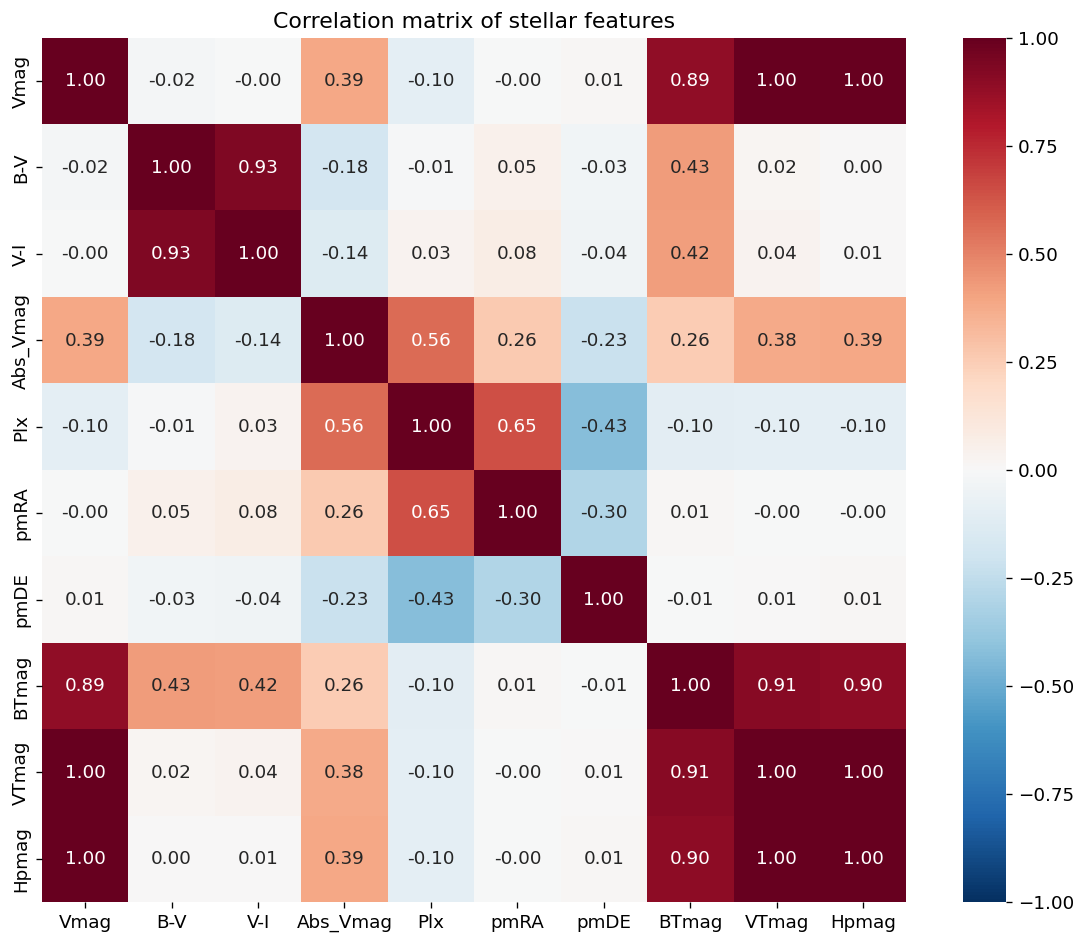


Notice:
  - Photometric bands (Vmag, BTmag, VTmag, Hpmag) are very strongly correlated
  - Colour indices (B-V, V-I) correlate with each other (both trace temperature)
  - Proper motions (pmRA, pmDE) are largely uncorrelated with photometry


In [27]:
feature_cols = ['Vmag', 'B-V', 'V-I', 'Abs_Vmag', 'Plx', 'pmRA', 'pmDE', 
                'BTmag', 'VTmag', 'Hpmag']
data = df[feature_cols].copy()

print(f"Working with {len(feature_cols)} features and {len(data)} stars\n")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.2f', ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation matrix of stellar features')
plt.tight_layout()
plt.show()

print("\nNotice:")
print("  - Photometric bands (Vmag, BTmag, VTmag, Hpmag) are very strongly correlated")
print("  - Colour indices (B-V, V-I) correlate with each other (both trace temperature)")
print("  - Proper motions (pmRA, pmDE) are largely uncorrelated with photometry")

## The core idea: Variance = Information

Can we mathematically quantify how much information a feature carries? The answer is **variance**.

- A feature where all stars have nearly the same value carries almost no information (you can't distinguish stars with it).
- A feature with a large spread carries a lot of information.

$$\text{Var}(X) = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

**PCA finds the directions in feature space along which the data varies the most.** These directions are the Principal Components.

---
## Part 1: PCA from Scratch

We implement PCA step-by-step using only NumPy and matplotlib, so you understand exactly what happens at each stage.

### Geometric intuition in 2D

Before tackling 10 dimensions, let's see PCA geometrically in 2D. We use two features that astrophysicists know well: **B-V** (colour index, proxy for temperature) and **Abs_Vmag** (absolute magnitude, intrinsic brightness). Together, they form the axes of the famous **Hertzsprung-Russell diagram**.

We standardize first, compute the 2x2 covariance matrix, and find its eigenvectors. The eigenvectors point along the directions of maximum and minimum spread -- they *are* the principal components.

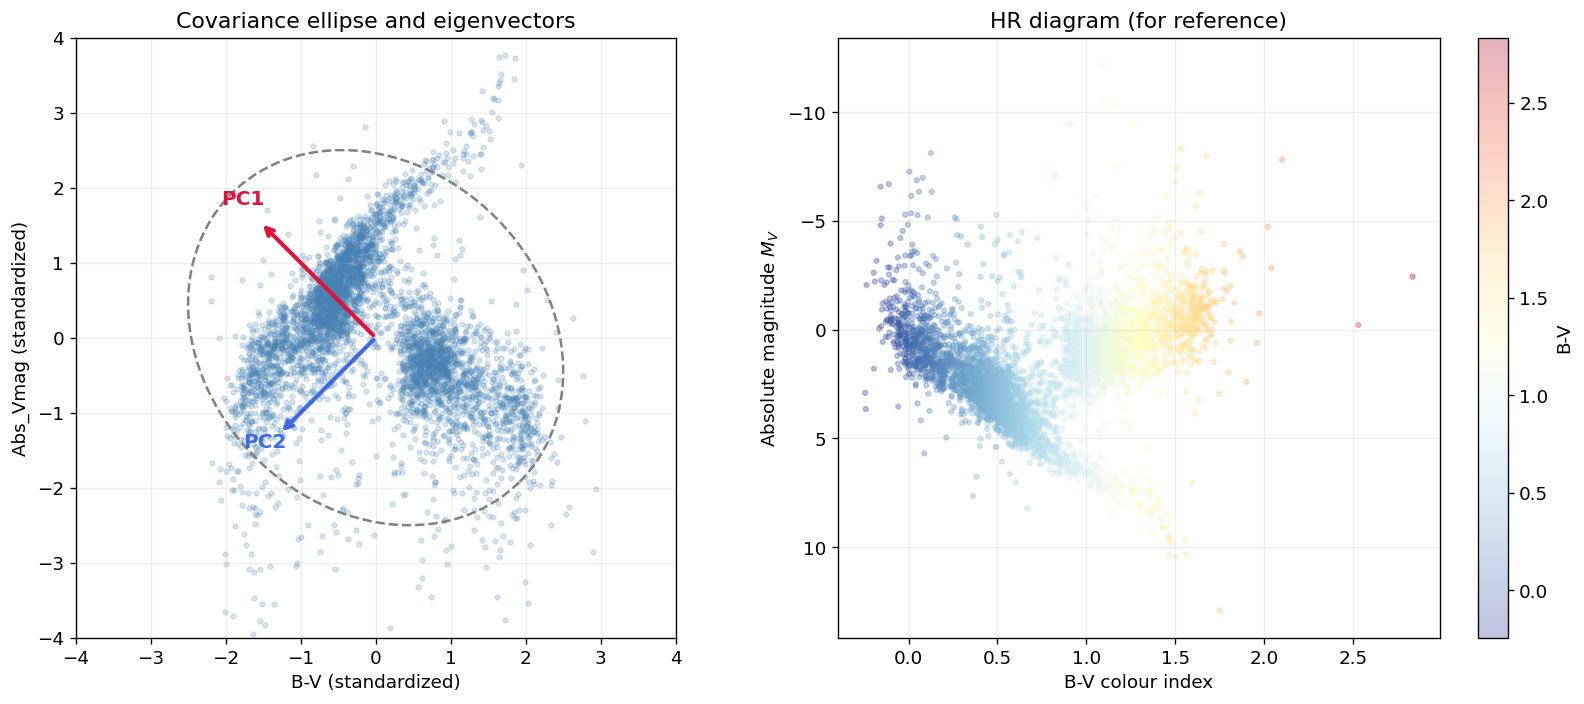

Eigenvalues: [1.1805 0.8199]
PC1 captures 59.0% of the 2D variance


In [28]:
# 2D demo: B-V vs Abs_Vmag
x_2d = data[['B-V', 'Abs_Vmag']].values
x_2d_mean = x_2d.mean(axis=0)
x_2d_std = x_2d.std(axis=0)
x_2d_s = (x_2d - x_2d_mean) / x_2d_std

# Covariance and eigen
cov_2d = np.cov(x_2d_s, rowvar=False)
eigvals_2d, eigvecs_2d = np.linalg.eigh(cov_2d)
order_2d = np.argsort(eigvals_2d)[::-1]
eigvals_2d = eigvals_2d[order_2d]
eigvecs_2d = eigvecs_2d[:, order_2d]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: standardized data + eigenvectors + ellipse
ax1.scatter(x_2d_s[:, 0], x_2d_s[:, 1], alpha=0.2, s=8, color='steelblue')

colors_arrow = ['crimson', 'royalblue']
labels_arrow = ['PC1', 'PC2']
for j in range(2):
    vec = eigvecs_2d[:, j] * np.sqrt(eigvals_2d[j]) * 2
    ax1.annotate('', xy=vec, xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color=colors_arrow[j], lw=2.5))
    ax1.text(vec[0]*1.15, vec[1]*1.15, labels_arrow[j], color=colors_arrow[j], 
             fontsize=12, fontweight='bold', ha='center')

# Covariance ellipse
pearson = cov_2d[0, 1] / np.sqrt(cov_2d[0, 0] * cov_2d[1, 1])
ell_radius_x = np.sqrt(1 + pearson)
ell_radius_y = np.sqrt(1 - pearson)
ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                  facecolor='none', edgecolor='gray', linestyle='--', linewidth=1.5)
scale_x = np.sqrt(cov_2d[0, 0]) * 2.5
scale_y = np.sqrt(cov_2d[1, 1]) * 2.5
transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y) + ax1.transData
ellipse.set_transform(transf)
ax1.add_patch(ellipse)

ax1.set_xlabel('B-V (standardized)')
ax1.set_ylabel('Abs_Vmag (standardized)')
ax1.set_title('Covariance ellipse and eigenvectors')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.2)
ax1.set_xlim(-4, 4)
ax1.set_ylim(-4, 4)

# Right: the actual HR diagram for reference
sc2 = ax2.scatter(data['B-V'], data['Abs_Vmag'], c=data['B-V'], cmap='RdYlBu_r', 
                  alpha=0.3, s=8)
ax2.invert_yaxis()
ax2.set_xlabel('B-V colour index')
ax2.set_ylabel('Absolute magnitude $M_V$')
ax2.set_title('HR diagram (for reference)')
ax2.grid(True, alpha=0.2)
plt.colorbar(sc2, ax=ax2, label='B-V')

plt.tight_layout()
plt.show()

print(f"Eigenvalues: {eigvals_2d.round(4)}")
print(f"PC1 captures {eigvals_2d[0]/eigvals_2d.sum()*100:.1f}% of the 2D variance")

**What did we just see?**

- The **eigenvectors** of the covariance matrix point along the directions of maximum (PC1) and minimum (PC2) spread.
- PC1 is the long axis of the data ellipse, PC2 is the short axis -- **perpendicular** by construction.
- PCA is essentially **rotating the coordinate system** to align with the data's natural shape.

Now let's do this properly on all 10 features.

### Step 1: Standardization (z-score normalisation)

**Why standardize?** PCA maximizes variance. If one feature ranges from -500 to +500 (proper motion in mas/yr) and another from 0 to 12 (magnitude), the proper motion will dominate PC1 simply because its *numbers* are bigger -- not because it carries more information.

**Fix:** subtract the mean and divide by the standard deviation. After this, every feature has mean 0 and variance 1, so they compete on equal footing.

$$z = \frac{x - \mu}{\sigma}$$

**Rule:** always standardize unless you have a specific reason not to.

In [29]:
X = data.values

means = X.mean(axis=0)
stds = X.std(axis=0, ddof=1)
X_std = (X - means) / stds

print("Before standardization:")
for i, col in enumerate(feature_cols):
    print(f"  {col:10s}  mean={X[:, i].mean():8.2f}  std={X[:, i].std(ddof=1):8.3f}")

print("\nAfter standardization:")
for i, col in enumerate(feature_cols):
    print(f"  {col:10s}  mean={X_std[:, i].mean():8.5f}  std={X_std[:, i].std(ddof=1):8.5f}")

Before standardization:
  Vmag        mean=    8.37  std=   1.204
  B-V         mean=    0.73  std=   0.444
  V-I         mean=    0.79  std=   0.500
  Abs_Vmag    mean=    1.79  std=   2.290
  Plx         mean=    7.51  std=  10.350
  pmRA        mean=   30.76  std= 131.554
  pmDE        mean=  -18.23  std=  67.152
  BTmag       mean=    9.29  std=   1.322
  VTmag       mean=    8.45  std=   1.201
  Hpmag       mean=    8.48  std=   1.211

After standardization:
  Vmag        mean= 0.00000  std= 1.00000
  B-V         mean= 0.00000  std= 1.00000
  V-I         mean= 0.00000  std= 1.00000
  Abs_Vmag    mean=-0.00000  std= 1.00000
  Plx         mean= 0.00000  std= 1.00000
  pmRA        mean= 0.00000  std= 1.00000
  pmDE        mean=-0.00000  std= 1.00000
  BTmag       mean= 0.00000  std= 1.00000
  VTmag       mean=-0.00000  std= 1.00000
  Hpmag       mean=-0.00000  std= 1.00000


### Step 2: Compute the covariance matrix

The covariance matrix captures how each pair of features varies together:
- **Diagonal** elements: variance of each feature (all $\approx 1$ after standardization)
- **Off-diagonal** elements: covariance between features (positive = increase together, negative = one increases while the other decreases)

$$C_{ij} = \frac{1}{n-1}\sum_{k=1}^{n}(x_{ki} - \bar{x}_i)(x_{kj} - \bar{x}_j)$$

For standardized data this simplifies to:

$$C = \frac{1}{n-1} X^T X$$

Covariance matrix shape: (10, 10)
Diagonal values (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]



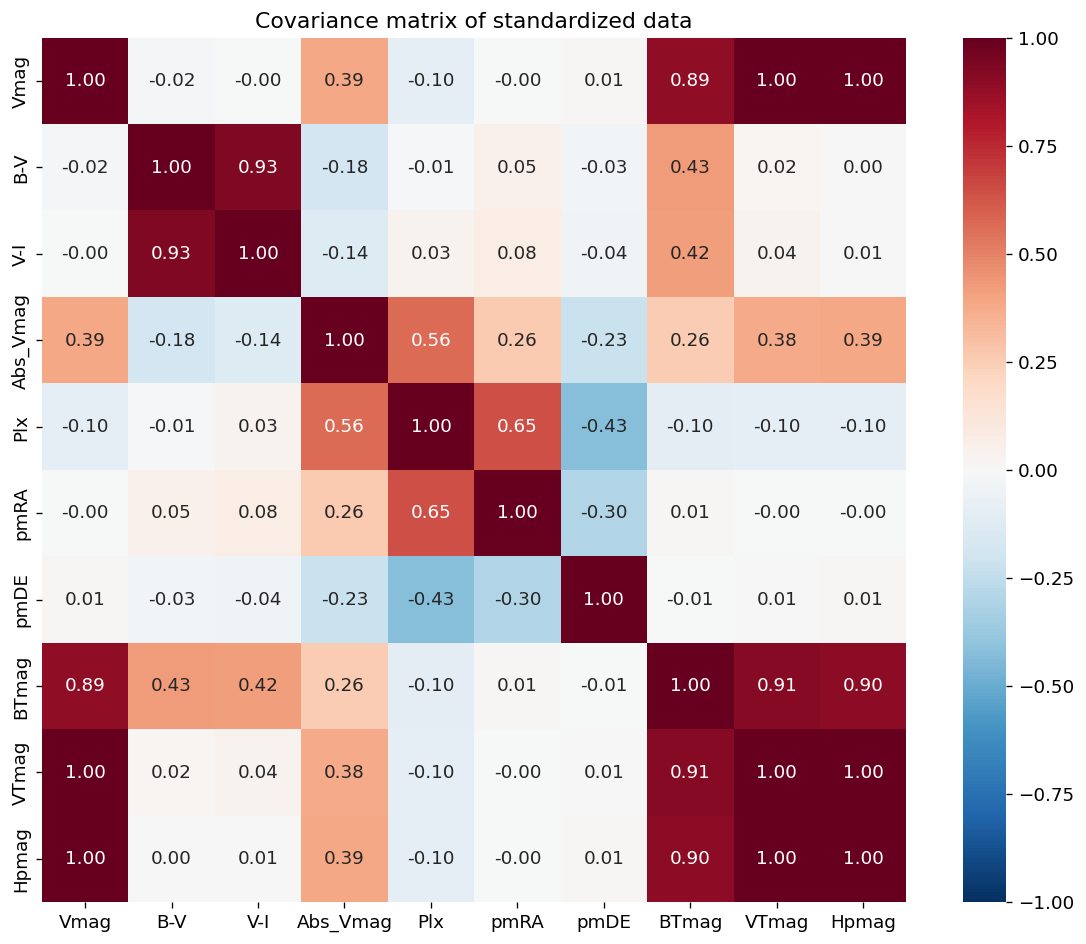

In [30]:
n = X_std.shape[0]
cov_matrix = (X_std.T @ X_std) / (n - 1)

print(f"Covariance matrix shape: {cov_matrix.shape}")
print(f"Diagonal values (should be ~1): {np.diag(cov_matrix).round(4)}\n")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=feature_cols, yticklabels=feature_cols, square=True, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Covariance matrix of standardized data')
plt.tight_layout()
plt.show()

### Step 3: Eigendecomposition -- the mathematical heart of PCA

We decompose the covariance matrix into:

$$C = V \Lambda V^T$$

where:
- $V$ is the matrix whose **columns are the eigenvectors** -- these are the directions of the principal components
- $\Lambda$ is the diagonal matrix of **eigenvalues** $\lambda_i$ -- these are the variances along each PC direction

Each eigenvector defines a new axis in feature space. Each eigenvalue tells us how much of the total variance lies along that axis. We sort them in decreasing order: PC1 captures the most variance, PC2 the second most, etc.

In [31]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort by decreasing eigenvalue
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("Eigenvalues (= variance along each PC):")
for i, val in enumerate(eigenvalues):
    print(f"  PC{i+1:2d}: {val:.4f}")

print(f"\nSum of eigenvalues: {eigenvalues.sum():.4f}")
print(f"Number of features:  {len(feature_cols)}")
print("(These should be equal -- total variance is conserved by the rotation)")

Eigenvalues (= variance along each PC):
  PC 1: 4.0457
  PC 2: 2.2498
  PC 3: 2.0920
  PC 4: 0.7438
  PC 5: 0.6083
  PC 6: 0.1828
  PC 7: 0.0709
  PC 8: 0.0050
  PC 9: 0.0012
  PC10: 0.0004

Sum of eigenvalues: 10.0000
Number of features:  10
(These should be equal -- total variance is conserved by the rotation)


### Step 4: The scree plot -- how many PCs to keep?

Each PC explains a fraction of the total variance. The **scree plot** shows the explained variance per component. Look for the **"elbow"** -- the point of diminishing returns.

**Rule of thumb:** keep enough PCs to explain ~90% of the total variance. Dropping the rest is **lossy compression** -- a small loss of information for a massive gain in simplicity.

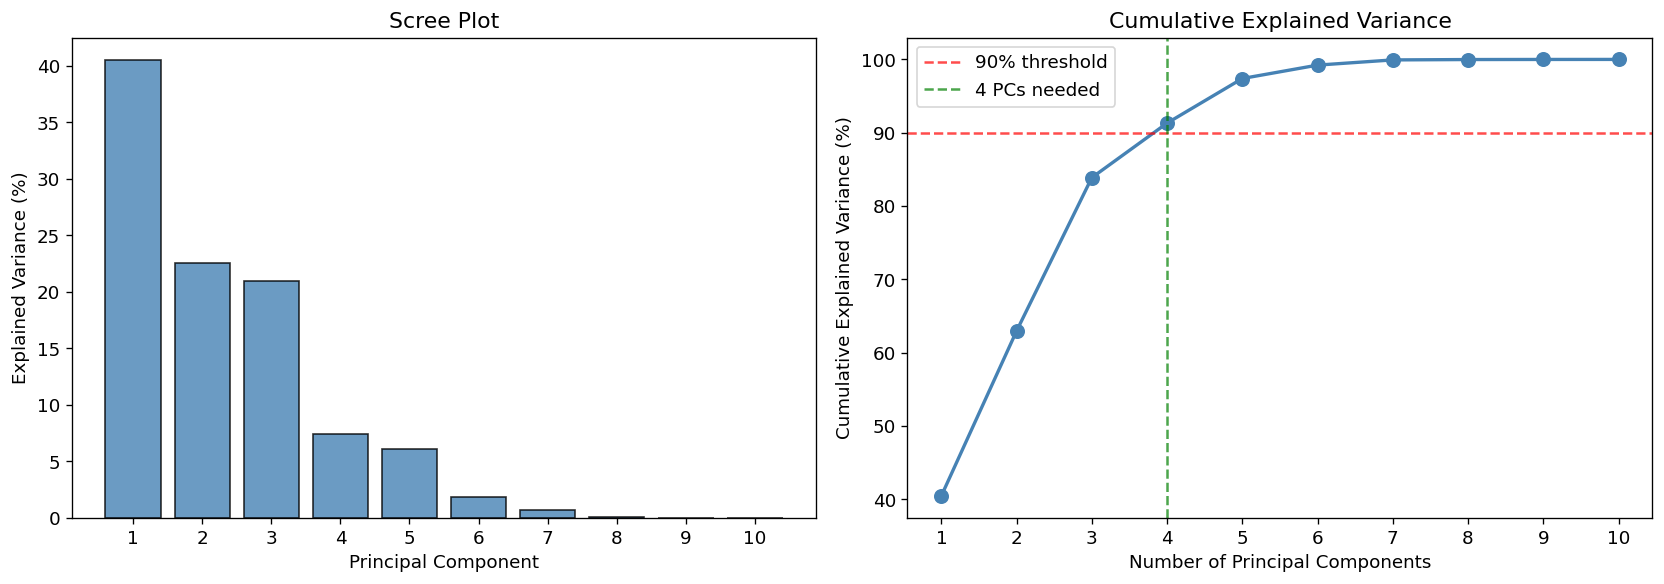

To explain 90% of the variance, we need 4 PCs (out of 10).

  PC 1:  40.5%  (cumulative:  40.5%)
  PC 2:  22.5%  (cumulative:  63.0%)
  PC 3:  20.9%  (cumulative:  83.9%)
  PC 4:   7.4%  (cumulative:  91.3%) <-- 90% reached
  PC 5:   6.1%  (cumulative:  97.4%)
  PC 6:   1.8%  (cumulative:  99.2%)
  PC 7:   0.7%  (cumulative:  99.9%)
  PC 8:   0.1%  (cumulative: 100.0%)
  PC 9:   0.0%  (cumulative: 100.0%)
  PC10:   0.0%  (cumulative: 100.0%)


In [32]:
explained_ratio = eigenvalues / eigenvalues.sum()
cumulative_ratio = np.cumsum(explained_ratio)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Individual
ax1.bar(range(1, len(explained_ratio)+1), explained_ratio * 100, 
        color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Scree Plot')
ax1.set_xticks(range(1, len(explained_ratio)+1))

# Cumulative
ax2.plot(range(1, len(cumulative_ratio)+1), cumulative_ratio * 100, 
         'o-', color='steelblue', linewidth=2, markersize=8)
ax2.axhline(y=90, color='red', linestyle='--', alpha=0.7, label='90% threshold')
n_90 = int(np.argmax(cumulative_ratio >= 0.90) + 1)
ax2.axvline(x=n_90, color='green', linestyle='--', alpha=0.7, label=f'{n_90} PCs needed')
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.set_xticks(range(1, len(cumulative_ratio)+1))
ax2.legend()

plt.tight_layout()
plt.show()

print(f"To explain 90% of the variance, we need {n_90} PCs (out of {len(feature_cols)}).\n")
for i, (e, c) in enumerate(zip(explained_ratio, cumulative_ratio)):
    marker = " <-- 90% reached" if i + 1 == n_90 else ""
    print(f"  PC{i+1:2d}: {e*100:5.1f}%  (cumulative: {c*100:5.1f}%){marker}")

### Step 5: Project the data onto the principal components

Now we transform the data into the new coordinate system. Each star gets new coordinates: its projections onto each PC.

$$\mathbf{z} = V_k^T \, \mathbf{x}$$

where $V_k$ contains the first $k$ eigenvectors (the ones we decided to keep).

In [33]:
n_components = n_90

W = eigenvectors[:, :n_components]  # projection matrix (p x k)
X_pca = X_std @ W                   # project!

print(f"Original data shape:  {X_std.shape}  ({X_std.shape[1]} features)")
print(f"Projected data shape: {X_pca.shape}  ({X_pca.shape[1]} PCs)")
print(f"\nDimensionality reduction: {X_std.shape[1]}D  -->  {X_pca.shape[1]}D")

Original data shape:  (4695, 10)  (10 features)
Projected data shape: (4695, 4)  (4 PCs)

Dimensionality reduction: 10D  -->  4D


### Step 6: Visualise the results -- does the HR diagram emerge?

The moment of truth. We plot PC1 vs PC2, colouring each star by its **B-V colour index** (a proxy for surface temperature). If PCA has captured the astrophysics, we should see structure reminiscent of the **Hertzsprung-Russell diagram** -- without ever telling PCA that colour and brightness are the important variables.

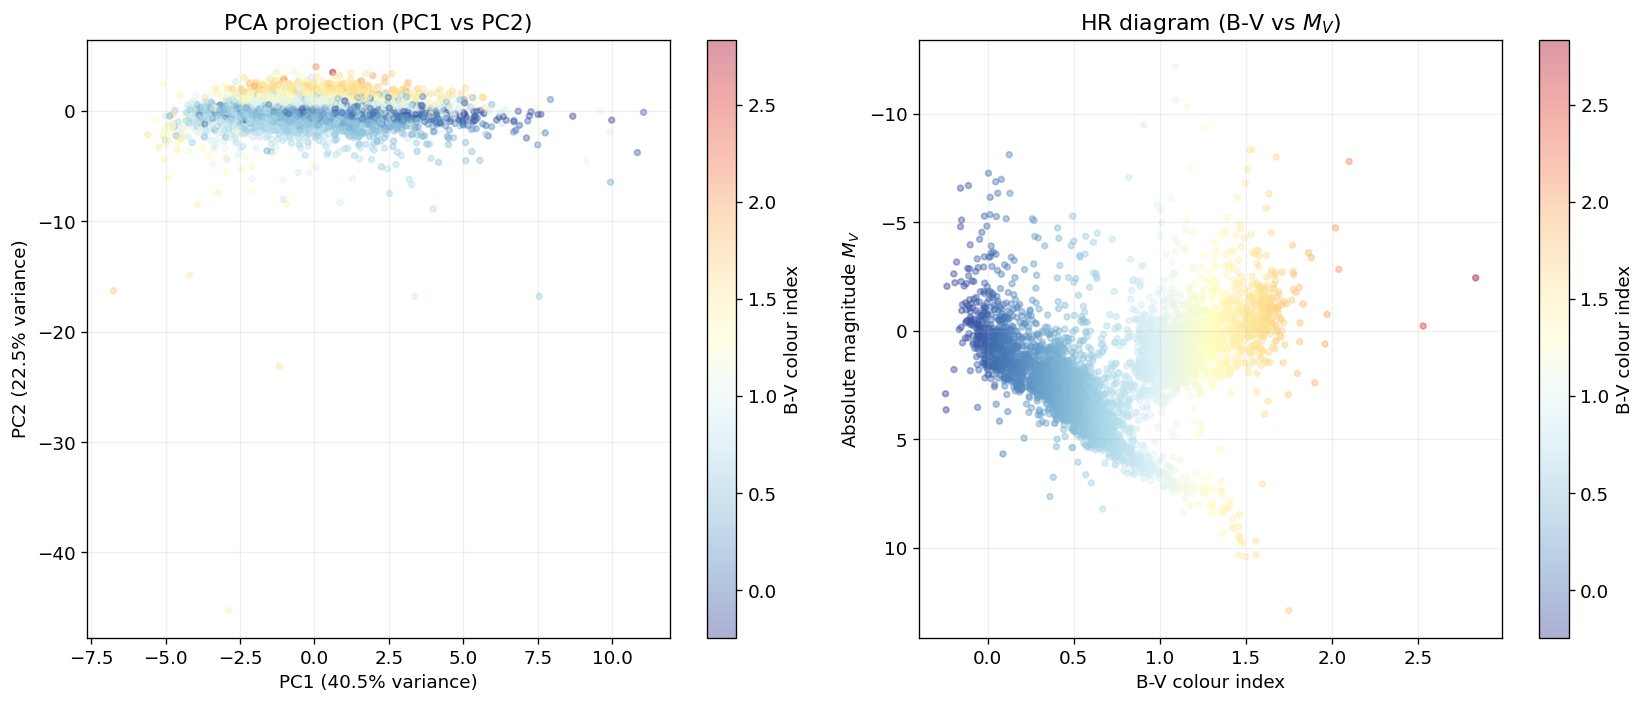

The colour-magnitude structure is visible in the PCA projection!
PCA has discovered the dominant astrophysical correlations from the full feature set,
without us telling it that colour and brightness matter.


In [34]:
bv = data['B-V'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: PCA projection
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=bv, cmap='RdYlBu_r', 
                  alpha=0.4, s=12, rasterized=True)
ax1.set_xlabel(f'PC1 ({explained_ratio[0]*100:.1f}% variance)')
ax1.set_ylabel(f'PC2 ({explained_ratio[1]*100:.1f}% variance)')
ax1.set_title('PCA projection (PC1 vs PC2)')
plt.colorbar(sc1, ax=ax1, label='B-V colour index')
ax1.grid(True, alpha=0.2)

# Right: the actual HR diagram for comparison
sc2 = ax2.scatter(data['B-V'], data['Abs_Vmag'], c=bv, cmap='RdYlBu_r', 
                  alpha=0.4, s=12, rasterized=True)
ax2.set_xlabel('B-V colour index')
ax2.set_ylabel('Absolute magnitude $M_V$')
ax2.set_title('HR diagram (B-V vs $M_V$)')
ax2.invert_yaxis()  # bright stars (low magnitude) at the top
plt.colorbar(sc2, ax=ax2, label='B-V colour index')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("The colour-magnitude structure is visible in the PCA projection!")
print("PCA has discovered the dominant astrophysical correlations from the full feature set,")
print("without us telling it that colour and brightness matter.")

### Step 7: Interpreting the principal components

PCs are **linear combinations** of the original features. Each PC is a weighted sum of the original variables:

$$\text{PC}_j = \sum_i w_{ij} \cdot x_i$$

The weights $w_{ij}$ are called **loadings** (they are the eigenvector components). We can visualise them as arrows in a **biplot**:

- **Direction** of the arrow: which way does this feature push points in PC space?
- **Length** of the arrow: how strongly does this feature contribute?
- **Angle between arrows**: correlation between features. Same direction = positive correlation, opposite = negative, perpendicular = uncorrelated.

In [35]:
loadings = pd.DataFrame(
    eigenvectors[:, :n_components],
    index=feature_cols,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
print("Loadings (contribution of each original feature to each PC):\n")
print(loadings.round(3).to_string())

Loadings (contribution of each original feature to each PC):

            PC1    PC2    PC3    PC4
Vmag     -0.486  0.003  0.131 -0.024
B-V      -0.081  0.242 -0.619  0.032
V-I      -0.086  0.214 -0.624  0.054
Abs_Vmag -0.216 -0.451  0.049  0.199
Plx       0.016 -0.575 -0.232  0.196
pmRA     -0.021 -0.457 -0.253  0.327
pmDE      0.015  0.372  0.198  0.899
BTmag    -0.474  0.117 -0.159 -0.014
VTmag    -0.489  0.013  0.104 -0.024
Hpmag    -0.488  0.005  0.121 -0.023


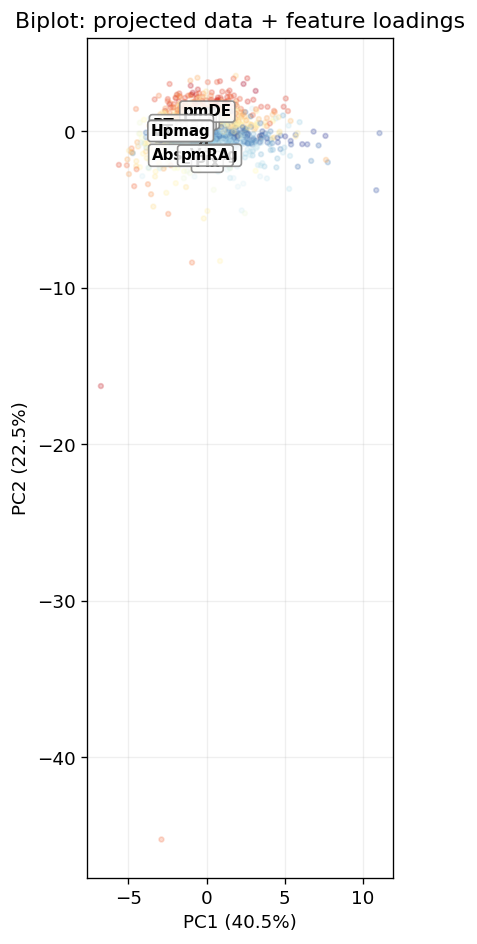

Reading the biplot:
  - Features pointing in the same direction are positively correlated
  - Features pointing in opposite directions are negatively correlated
  - Perpendicular arrows indicate little correlation
  - Longer arrows = stronger contribution to these PCs


In [36]:
# Biplot
fig, ax = plt.subplots(figsize=(10, 8))

idx_sub = np.random.choice(len(X_pca), size=min(1500, len(X_pca)), replace=False)
ax.scatter(X_pca[idx_sub, 0], X_pca[idx_sub, 1], c=bv[idx_sub], cmap='RdYlBu_r', 
           alpha=0.25, s=8, rasterized=True)

scale = 3.0
for i, feat in enumerate(feature_cols):
    dx = loadings.iloc[i, 0] * scale
    dy = loadings.iloc[i, 1] * scale
    ax.arrow(0, 0, dx, dy, head_width=0.07, head_length=0.04, 
             fc='black', ec='black', linewidth=1.2)
    ax.text(dx * 1.13, dy * 1.13, feat, fontsize=9, ha='center', va='center',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.85))

ax.set_xlabel(f'PC1 ({explained_ratio[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_ratio[1]*100:.1f}%)')
ax.set_title('Biplot: projected data + feature loadings')
ax.grid(True, alpha=0.2)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("Reading the biplot:")
print("  - Features pointing in the same direction are positively correlated")
print("  - Features pointing in opposite directions are negatively correlated")
print("  - Perpendicular arrows indicate little correlation")
print("  - Longer arrows = stronger contribution to these PCs")

### Step 8: Reconstruction and information loss

PCA with fewer components is **lossy compression**. We can project back to the original space:

$$\hat{X}_{\text{std}} = Z \cdot V_k^T$$

then un-standardize to get back to physical units. The difference between the original and reconstructed values is the **information we lost** by keeping only $k$ PCs.

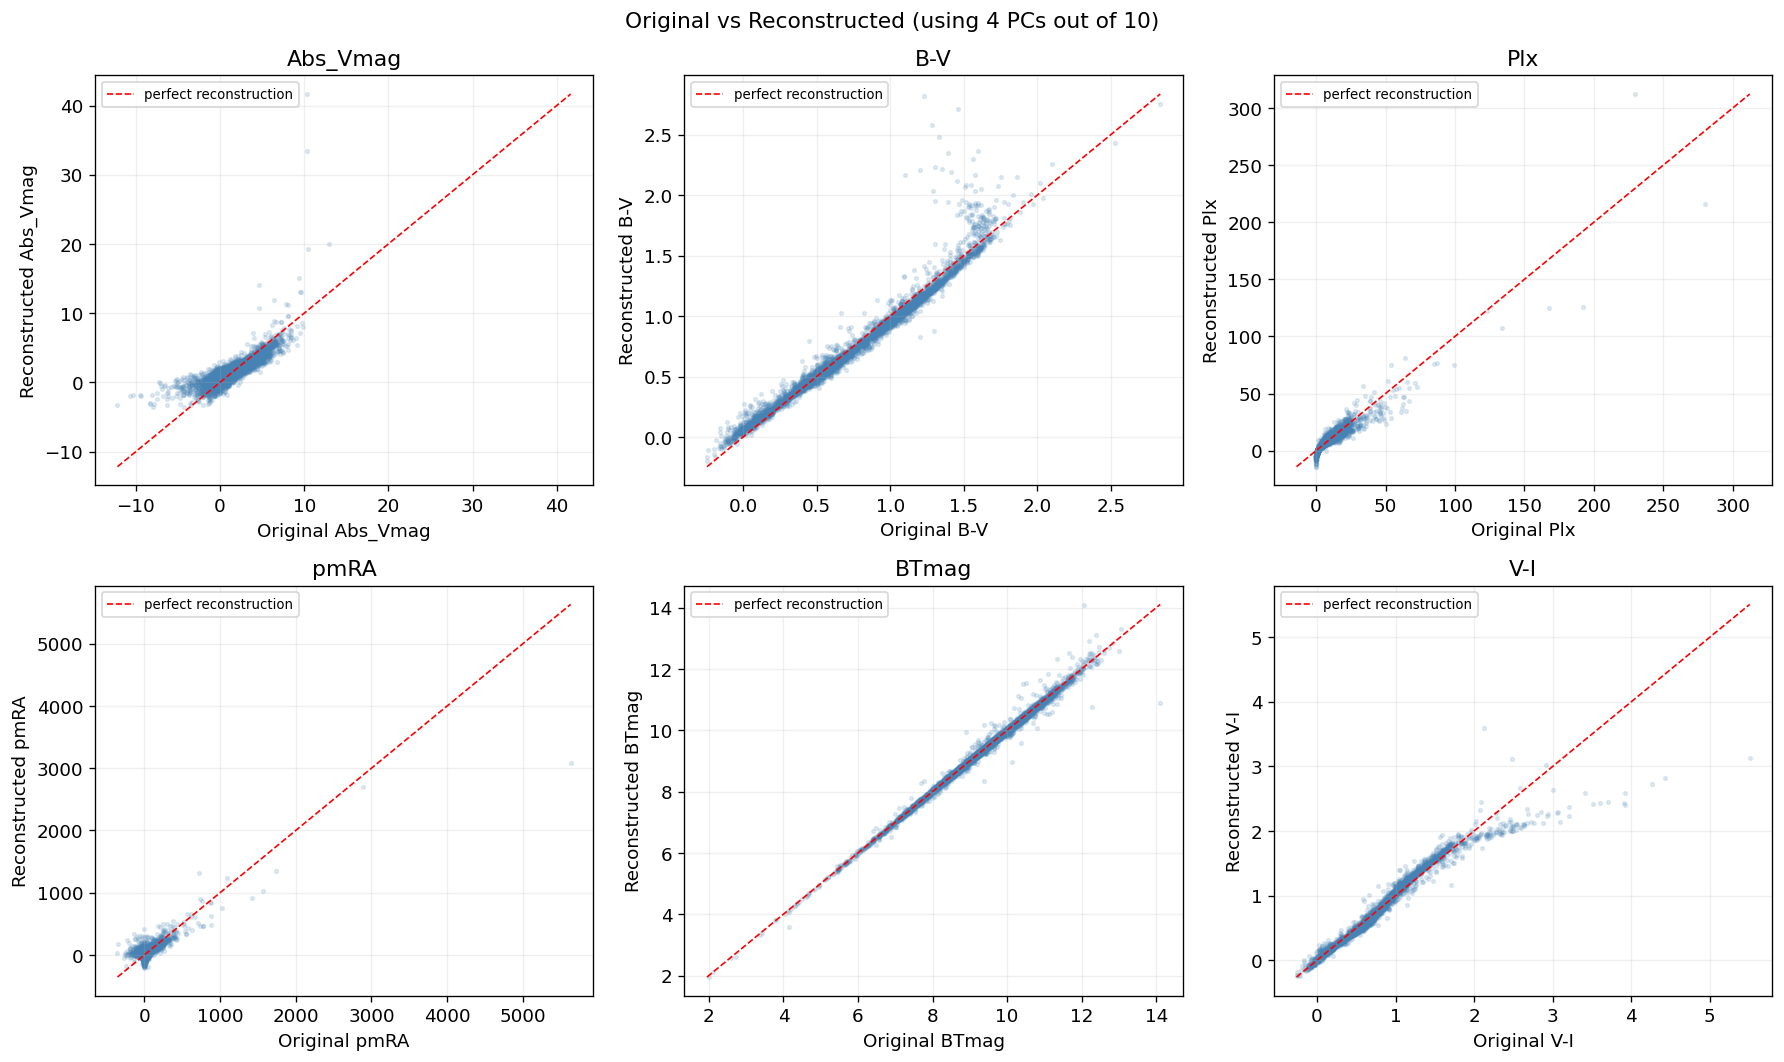

Mean squared reconstruction error per feature:
  Vmag      : 0.0121
  B-V       : 0.0076
  V-I       : 0.0123
  Abs_Vmag  : 1.6660
  Plx       : 12.2664
  pmRA      : 5459.4926
  pmDE      : 15.5970
  BTmag     : 0.0126
  VTmag     : 0.0107
  Hpmag     : 0.0096


In [37]:
# Reconstruct
X_reconstructed_std = X_pca @ W.T
X_reconstructed = X_reconstructed_std * stds + means

# Compare original vs reconstructed for selected features
features_to_show = ['Abs_Vmag', 'B-V', 'Plx', 'pmRA', 'BTmag', 'V-I']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, feat in zip(axes.ravel(), features_to_show):
    idx_f = feature_cols.index(feat)
    orig = X[:, idx_f]
    recon = X_reconstructed[:, idx_f]
    ax.scatter(orig, recon, alpha=0.15, s=5, color='steelblue', rasterized=True)
    lims = [min(orig.min(), recon.min()), max(orig.max(), recon.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='perfect reconstruction')
    ax.set_xlabel(f'Original {feat}')
    ax.set_ylabel(f'Reconstructed {feat}')
    ax.set_title(feat)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)

plt.suptitle(f'Original vs Reconstructed (using {n_components} PCs out of {len(feature_cols)})', fontsize=13)
plt.tight_layout()
plt.show()

print("Mean squared reconstruction error per feature:")
mse_per_feature = np.mean((X - X_reconstructed)**2, axis=0)
for feat, mse in zip(feature_cols, mse_per_feature):
    print(f"  {feat:10s}: {mse:.4f}")

### PCA assumptions and limitations

Before moving on, keep these in mind:

**Assumptions:**
- Relationships between variables are **linear** -- if your data lives on a curve, PCA will miss it
- **Variance = information** -- not always true (noise can have high variance!)
- Data should be **mean-centered** -- always center (or standardize) before applying PCA
- Features should be on the **same scale** -- always standardize unless you have a reason not to

**Limitations:**
- PCA is **unsupervised**: it ignores any labels or classes you may have
- It only captures **linear** structure
- It is **sensitive to outliers** (a single extreme star can distort the PCs)
- PCs are often **hard to interpret physically** (they are mixtures of all original features)

**Pros:**
- Reduces dimensionality while keeping most information
- Removes redundancy (correlated features collapse into one PC)
- Speeds up downstream models
- Enables visualisation of high-dimensional data

---
## Part 2: PCA with Scikit-Learn

Now that we understand every step of the algorithm, let's see how **scikit-learn** reduces all of Part 1 to a handful of lines.

In [38]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.values)

# Fit PCA (all components first, to see the scree plot)
pca = PCA()
X_pca_sk = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_.round(4))
print(f"\nCumulative: {np.cumsum(pca.explained_variance_ratio_).round(4)}")

Explained variance ratio:
[4.046e-01 2.250e-01 2.092e-01 7.440e-02 6.080e-02 1.830e-02 7.100e-03
 5.000e-04 1.000e-04 0.000e+00]

Cumulative: [0.4046 0.6296 0.8387 0.9131 0.974  0.9922 0.9993 0.9998 1.     1.    ]


### Comparing manual vs sklearn

Let's verify that our from-scratch implementation gives the same results.

**Note:** eigenvectors are defined up to a sign ($\vec{v}$ and $-\vec{v}$ are both valid eigenvectors). So the PCA projections may be *mirrored* along one or both axes -- this is perfectly normal and does not affect the results.

Explained variance comparison:
  Manual:  [4.046e-01 2.250e-01 2.092e-01 7.440e-02 6.080e-02 1.830e-02 7.100e-03
 5.000e-04 1.000e-04 0.000e+00]
  Sklearn: [4.046e-01 2.250e-01 2.092e-01 7.440e-02 6.080e-02 1.830e-02 7.100e-03
 5.000e-04 1.000e-04 0.000e+00]


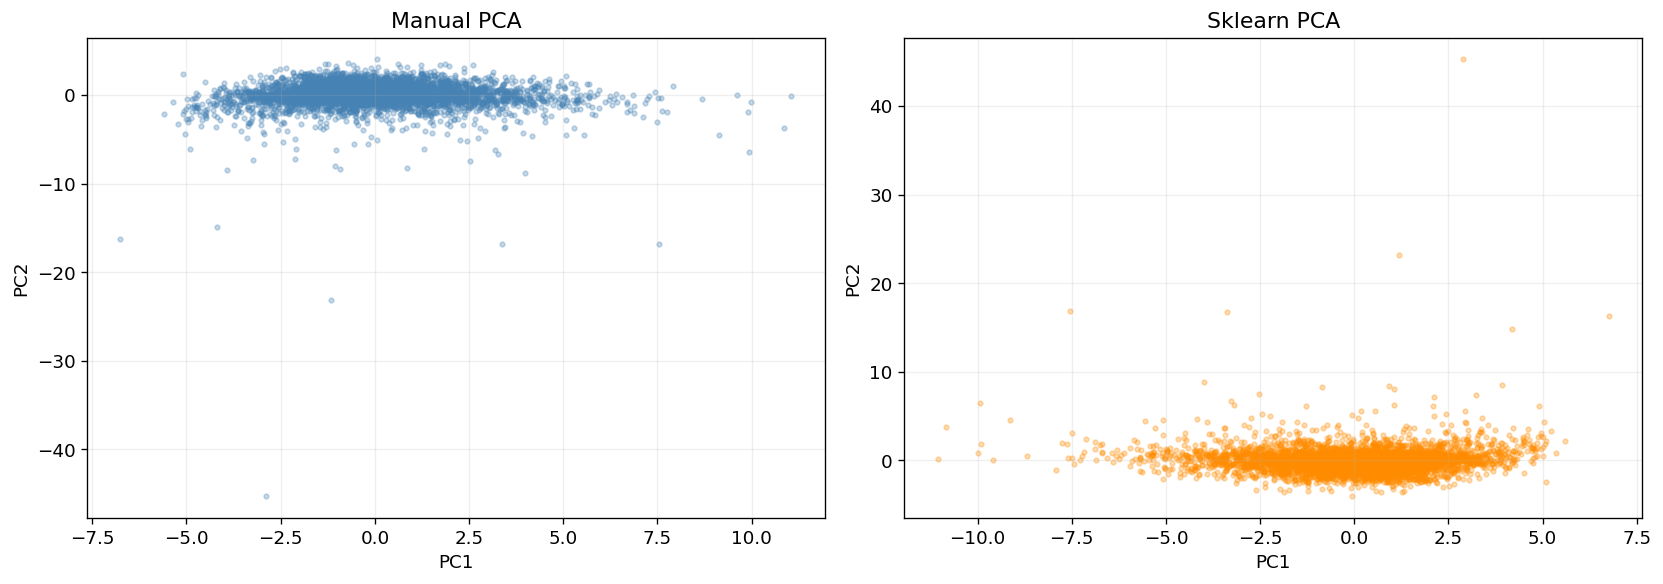


The plots may be mirrored (sign flip) -- this is expected.
The variance explained is identical: our implementation is correct.


In [39]:
print("Explained variance comparison:")
print(f"  Manual:  {explained_ratio.round(4)}")
print(f"  Sklearn: {pca.explained_variance_ratio_.round(4)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=8, color='steelblue', rasterized=True)
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.set_title('Manual PCA')
ax1.grid(True, alpha=0.2)

ax2.scatter(X_pca_sk[:, 0], X_pca_sk[:, 1], alpha=0.3, s=8, color='darkorange', rasterized=True)
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.set_title('Sklearn PCA')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("\nThe plots may be mirrored (sign flip) -- this is expected.")
print("The variance explained is identical: our implementation is correct.")

### Useful sklearn attributes

The `PCA` object gives you everything out of the box:
- `pca.components_` -- the loadings matrix (each row = one PC)
- `pca.explained_variance_ratio_` -- fraction of variance per PC
- `pca.n_components_` -- number of components kept
- `pca.transform(X_new)` -- project new data onto the PCs
- `pca.inverse_transform(Z)` -- reconstruct from PC coordinates

In [40]:
# PCA with a fixed number of components + reconstruction
pca_reduced = PCA(n_components=n_90)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)
X_recon_sk = scaler.inverse_transform(pca_reduced.inverse_transform(X_pca_reduced))

print(f"Components shape: {pca_reduced.components_.shape}")
print(f"  (each row = one PC, each column = one original feature)\n")

mse_sk = np.mean((data.values - X_recon_sk)**2, axis=0)
print(f"Reconstruction MSE (sklearn, {n_90} PCs):")
for feat, mse in zip(feature_cols, mse_sk):
    print(f"  {feat:10s}: {mse:.4f}")

Components shape: (4, 10)
  (each row = one PC, each column = one original feature)

Reconstruction MSE (sklearn, 4 PCs):
  Vmag      : 0.0121
  B-V       : 0.0076
  V-I       : 0.0123
  Abs_Vmag  : 1.6660
  Plx       : 12.2664
  pmRA      : 5459.4926
  pmDE      : 15.5970
  BTmag     : 0.0126
  VTmag     : 0.0107
  Hpmag     : 0.0096


### The Pipeline pattern

For production code, combine the scaler and PCA into a single **pipeline**. This ensures that the same standardization parameters are applied consistently when you transform new data.

In [41]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_90))
])

X_transformed = pipe.fit_transform(data.values)
print(f"Pipeline output shape: {X_transformed.shape}")
print(f"\nThe pipeline remembers the scaler parameters,")
print(f"so you can call pipe.transform(new_data) on unseen stars.")

Pipeline output shape: (4695, 4)

The pipeline remembers the scaler parameters,
so you can call pipe.transform(new_data) on unseen stars.


### When PCA is not enough -- alternatives

PCA optimises **variance**, not class separability. Good separation in PC space is not guaranteed, and no separation in PC space does not mean that classes are inseparable.

When PCA's linear assumptions fail, consider:

- **t-SNE**: preserves local neighbourhood structure, great for visualisation. But: non-deterministic, not interpretable, not a reusable transformation.
- **UMAP**: faster than t-SNE, better at preserving global structure. Becoming the standard for high-dimensional visualisation in astrophysics and biology.
- **Autoencoders**: neural-network version of PCA. Captures non-linear structure and scales to very high dimensions. But: needs training data, much less interpretable.

**Rule of thumb:** start with PCA. Move to UMAP or autoencoders only if the linear assumption clearly fails.

---
## Part 3: Your turn!

Choose a dataset -- from your own research, a public catalogue, or one of the suggestions below -- and apply PCA to explore its structure.

**Dataset ideas:**
- SDSS galaxy photometry (ugriz magnitudes + spectroscopic redshift) via `astroquery.sdss`
- Gaia DR3 stellar parameters via `astroquery.gaia`
- NASA Exoplanet Archive (orbital + physical parameters)
- 2MASS photometry (JHK bands)
- Any multi-column table from your own work

**Questions to guide your exploration:**
1. How many features do you have? How many PCs do you need for 90% of the variance?
2. Make a scree plot. Where is the elbow?
3. Plot PC1 vs PC2. Do you see any structure? Colour by a known label if you have one.
4. Look at the loadings / make a biplot. Which features drive PC1? Which are correlated?
5. Reconstruct the data with fewer PCs. How good is the reconstruction?

In [42]:
# Load your dataset here
# Example with Gaia (uncomment to use):
#
# from astroquery.gaia import Gaia
# job = Gaia.launch_job("""
#     SELECT TOP 2000 
#         teff_gspphot, logg_gspphot, mh_gspphot, 
#         ag_gspphot, ebpminrp_gspphot,
#         phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag,
#         parallax, pmra, pmdec
#     FROM gaiadr3.gaia_source
#     WHERE teff_gspphot IS NOT NULL
#       AND logg_gspphot IS NOT NULL
#       AND random_index < 100000
# """)
# df_new = job.get_results().to_pandas().dropna()
# print(df_new.shape)
# df_new.head()


In [ ]:
# Your PCA analysis here


In [ ]:
# Your visualisations here
